In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 
from typing import Optional  # change Optional[str] to str | None when using higher versions of python3

import os
import math
import re
from typing import Optional, Sequence, Dict, Any, List, Set, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
## data path
path_to_github_folder = "/Users/floorbroekgaarden/Projects/GitHub/"
path_to_file_folder = "Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/"
path_to_file = path_to_github_folder + path_to_file_folder


### Instructions 

for this code to work you will need the following files 
  - `DCOlabel + "_rates_review.csv"` For DCOlabel in BH-BH, BH-NS, and NS-NS  
 you can find this in the Zenodo file or on GitHub inside the Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/ folder 
  - it imports some functions from the `common_code` file above, but you dont need this :) (just uncomment if needed) 
  - likely you want to change the `save_path` in the code call below 
  

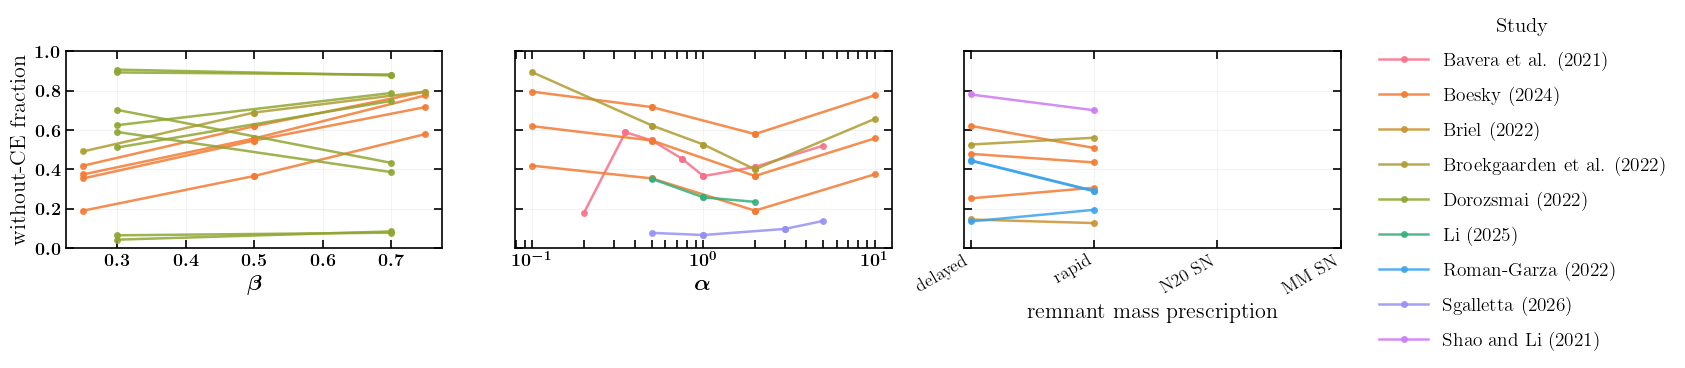

In [3]:


# plt.rcParams.update({
#     "font.size": 14,
#     "axes.labelsize": 16,
#     "axes.titlesize": 16,
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "legend.fontsize": 14,
#     "legend.title_fontsize": 15,
# })


# def plot_withoutCE_fraction_vs_parameters_static(
#     path_to_file: str,
#     parameters: Sequence[str],
#     DCOlabel: str = "BH-BH",
#     relation_file: Optional[str] = None,
#     rates_file: Optional[str] = None,
#     specs_file: str = "simulation_specs.csv",
#     ncols: int = 3,
#     panel_w_in: float = 5.2,   # inches per panel width
#     panel_h_in: float = 3.2,   # inches per panel height
#     marker_size: float = 4.0,  # matplotlib markersize (points)
#     line_width: float = 1.8,
#     line_alpha: float = 0.85,
#     palette_name: str = "husl",
#     show_study_legend: bool = True,
#     category_orders: Optional[Dict[str, List[str]]] = None,
#     alpha_logx: bool = True,
#     family_aliases: Optional[Dict[str, List[str]]] = None,
#     ylim: Tuple[float, float] = (0.0, 1.0),
# ):
#     """
#     Static Matplotlib version (no Plotly/Kaleido/nbformat/ipywidgets).

#     Each panel corresponds to one parameter family in `parameters`.
#     y-axis: fraction without common envelope (0..1)
#     x-axis: parameter value (numeric or categorical)
#     """

#     # ---------------- helpers ----------------
#     def parameter_family_from_travel_label(travel_label: str) -> str:
#         s = str(travel_label).strip()
#         if (not s) or (s.lower() == "nan"):
#             return "unknown"
#         s = s.replace("$", "").strip()
#         s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
#         s = s.replace("↑", "").replace("↓", "")
#         s = re.sub(r"\s+", " ", s).strip()
#         return s if s else "unknown"

#     def simplify_text(s: str) -> str:
#         t = str(s).lower()
#         t = t.replace("$", "")
#         t = re.sub(r"\s+", " ", t).strip()
#         t = re.sub(r"[^\w\s\\]", " ", t)
#         t = re.sub(r"\s+", " ", t).strip()
#         return t

#     def normalize_family(s: str) -> str:
#         t = simplify_text(s)

#         greek_map = {
#             r"\alpha": "alpha",
#             "α": "alpha",
#             "alpha": "alpha",
#             r"\beta": "beta",
#             "β": "beta",
#             "beta": "beta",
#             r"\gamma": "gamma",
#             "γ": "gamma",
#             "gamma": "gamma",
#         }
#         for k, v in greek_map.items():
#             if k in t:
#                 return v

#         if "remnant" in t and ("prescription" in t or "mass" in t):
#             return "remnant mass prescription"
#         if ("supernova" in t or "sn" in t) and "engine" in t:
#             return "supernova engine"
#         if "common envelope" in t or t.strip() == "ce" or " ce " in f" {t} ":
#             return "common envelope"

#         return t

#     def normalize_option(o: Any) -> str:
#         if o is None or (isinstance(o, float) and np.isnan(o)):
#             return ""
#         return str(o).strip().replace("$", "").strip()

#     def try_float(x: str) -> Optional[float]:
#         try:
#             return float(x)
#         except Exception:
#             return None

#     # ---------------- aliases ----------------
#     base_aliases = {
#         "alpha": ["alpha", r"\alpha", "α", "ce alpha", "common envelope efficiency", "alpha_ce", "alpha ce"],
#         "beta": ["beta", r"\beta", "β", "mass transfer efficiency", "mt efficiency", "accretion efficiency"],
#         "supernova engine": ["supernova engine", "sn engine", "engine", "delayed", "rapid"],
#         "remnant mass prescription": [
#             "remnant mass prescription", "remnant prescription", "remnant mass model",
#             "compact remnant prescription", "fryer", "delayed", "rapid"
#         ],
#     }
#     if family_aliases:
#         for k, v in family_aliases.items():
#             nk = normalize_family(k)
#             base_aliases.setdefault(nk, [])
#             base_aliases[nk].extend(v)

#     # ---------------- load relations ----------------
#     if relation_file is None:
#         relation_file = f"{DCOlabel}_fcRelations.csv"
#     rel_path = os.path.join(path_to_file, relation_file)
#     df_rel = pd.read_csv(rel_path)

#     required_rel_cols = {"legend", "from_modelname", "to_modelname", "travel_label", "from_option", "to_option"}
#     missing = required_rel_cols - set(df_rel.columns)
#     if missing:
#         raise ValueError(f"Relations file missing columns: {sorted(missing)}")

#     # ---------------- load rates ----------------
#     if rates_file is None:
#         rates_file = f"{DCOlabel}_rates_review.csv"
#     rates_path = os.path.join(path_to_file, rates_file)
#     df_rates = pd.read_csv(rates_path)

#     if "model" not in df_rates.columns:
#         raise ValueError("Rates file must include a 'model' column.")
#     if "fraction without common envelope" not in df_rates.columns:
#         raise ValueError("Rates file must include column 'fraction without common envelope'.")
#     df_rates = df_rates.set_index("model")

#     # ---------------- (optional) load specs ----------------
#     specs_path = os.path.join(path_to_file, specs_file)
#     if os.path.exists(specs_path):
#         df_specs = pd.read_csv(specs_path)
#         if "model" in df_specs.columns:
#             df_specs = df_specs.set_index("model")
#         else:
#             df_specs = pd.DataFrame().set_index(pd.Index([], name="model"))
#     else:
#         df_specs = pd.DataFrame().set_index(pd.Index([], name="model"))

#     # ---------------- annotate families ----------------
#     df_rel = df_rel.copy()
#     df_rel["family_raw"] = df_rel["travel_label"].apply(parameter_family_from_travel_label)
#     df_rel["family_simpl"] = df_rel["family_raw"].apply(simplify_text)
#     df_rel["family_norm"] = df_rel["family_raw"].apply(normalize_family)

#     def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
#         p_simpl = simplify_text(param_user)
#         p_norm = normalize_family(param_user)

#         m1 = df["family_norm"] == p_norm
#         m2 = df["family_simpl"].str.contains(re.escape(p_simpl), na=False) if p_simpl else False

#         aliases = [simplify_text(a) for a in base_aliases.get(p_norm, []) if a]
#         if aliases:
#             pat = "|".join(re.escape(a) for a in aliases if a)
#             m3 = df["family_simpl"].str.contains(pat, na=False)
#         else:
#             m3 = False

#         return df[m1 | m2 | m3].copy()

#     # ---------------- figure/grid ----------------
#     if category_orders is None:
#         category_orders = {}

#     n_panels = len(parameters)
#     ncols = max(1, int(ncols))
#     nrows = int(math.ceil(n_panels / ncols))

#     figsize = (panel_w_in * min(ncols, max(1, n_panels)), panel_h_in * nrows)
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False, sharey=True)

#     # colors by study (legend)
#     legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
#     palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))
#     color_map = {leg: palette[i % len(palette)] for i, leg in enumerate(legends_sorted)}

#     # legend handles: add one per study
#     legend_handles = {}
#     legend_labels = {}

#     # ---------------- plot panels ----------------
#     for k, p_user in enumerate(parameters):
#         r = k // ncols
#         c = k % ncols
#         ax = axes[r][c]

#         dfp = select_rows_for_parameter(df_rel, str(p_user))

#         if dfp.empty:
#             ax.text(0.5, 0.5, "No relations found for this parameter family",
#                     ha="center", va="center", transform=ax.transAxes, fontsize=10)
#             ax.set_ylim(*ylim)
#             ax.set_title(str(p_user))
#             continue

#         # Decide numeric vs categorical x by parsing ALL options in this panel
#         opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
#         opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
#         opts = [o for o in (opt_from + opt_to) if o != ""]
#         floats = [try_float(o) for o in opts]
#         is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

#         # category order for categorical axes
#         order = None
#         if str(p_user) in category_orders:
#             order = [str(x) for x in category_orders[str(p_user)]]
#         else:
#             low_opts = [o.lower() for o in opts]
#             if (not is_numeric) and ("delayed" in low_opts or "rapid" in low_opts):
#                 order = ["delayed", "rapid"]

#         if order is None and (not is_numeric):
#             seen = []
#             for o in opts:
#                 if o not in seen:
#                     seen.append(o)
#             order = seen

#         # map categories -> positions
#         cat_to_x = {}
#         if not is_numeric:
#             for i_cat, cat in enumerate(order):
#                 cat_to_x[cat] = i_cat

#         # plot segments grouped by study
#         for leg in sorted(dfp["legend"].dropna().unique().tolist()):
#             dfl = dfp[dfp["legend"] == leg]
#             col_rgb = color_map.get(leg, (0.5, 0.5, 0.5))

#             for _, rr in dfl.iterrows():
#                 m1 = rr["from_modelname"]
#                 m2 = rr["to_modelname"]
#                 if (m1 not in df_rates.index) or (m2 not in df_rates.index):
#                     continue

#                 y1 = float(df_rates.loc[m1, "fraction without common envelope"])
#                 y2 = float(df_rates.loc[m2, "fraction without common envelope"])

#                 xo1 = normalize_option(rr["from_option"])
#                 xo2 = normalize_option(rr["to_option"])
#                 if xo1 == "" or xo2 == "":
#                     continue

#                 if is_numeric:
#                     x1 = float(xo1)
#                     x2 = float(xo2)

#                     # log-x safety for alpha
#                     p_norm = normalize_family(str(p_user))
#                     if alpha_logx and (p_norm == "alpha") and (x1 <= 0 or x2 <= 0):
#                         continue
#                 else:
#                     # categorical positions
#                     if xo1 not in cat_to_x or xo2 not in cat_to_x:
#                         continue
#                     x1 = cat_to_x[xo1]
#                     x2 = cat_to_x[xo2]

#                 # actual static draw
#                 ax.plot(
#                     [x1, x2], [y1, y2],
#                     marker="o",
#                     markersize=marker_size,
#                     linewidth=line_width,
#                     alpha=line_alpha,
#                     color=col_rgb,
#                 )

#                 # create one legend handle per study
#                 if show_study_legend and (leg not in legend_handles):
#                     h, = ax.plot([], [], marker="o", linestyle="-", color=col_rgb,
#                                  markersize=marker_size, linewidth=line_width, alpha=line_alpha)
#                     legend_handles[leg] = h
#                     legend_labels[leg] = str(leg)

#         # axes formatting
        
#         ax.tick_params(
#             direction="in",
#             which="both",
#             top=True,
#             right=True,
#             length=6,
#             width=1.2
#         )
        
#         for spine in ax.spines.values():
#             spine.set_linewidth(1.2)
        
#         ax.set_ylim(*ylim)

#         if is_numeric:
#             p_norm = normalize_family(str(p_user))
#             if alpha_logx and (p_norm == "alpha"):
#                 ax.set_xscale("log")
#             ax.set_xlabel(str(p_user))
#         else:
#             ax.set_xticks(list(cat_to_x.values()))
#             ax.set_xticklabels(list(cat_to_x.keys()), rotation=30, ha="right")
#             ax.set_xlabel(str(p_user))

#         if c == 0:
#             ax.set_ylabel("without-CE fraction")

#         ax.grid(True, alpha=0.15, linewidth=0.8)

#     # hide unused panels
#     for j in range(n_panels, nrows * ncols):
#         rr = j // ncols
#         cc = j % ncols
#         axes[rr][cc].set_visible(False)

#     # global legend on the right
#     if show_study_legend and legend_handles:
#         # keep stable ordering
#         ordered_legs = [leg for leg in legends_sorted if leg in legend_handles]
#         handles = [legend_handles[leg] for leg in ordered_legs]
#         labels = [legend_labels[leg] for leg in ordered_legs]
#         fig.legend(
#             handles, labels,
#             title="Study",
#             loc="center left",
#             bbox_to_anchor=(0.88, 0.5),   # <-- move closer
#             frameon=False,
#             borderaxespad=0.5,
#             labelspacing=0.8,
#             handlelength=2.5
#         )

#         fig.tight_layout(rect=(0, 0, 0.88, 1))
    
#     return fig


# path = path_to_file
# DCOlabel = "BH-BH"

# fig = plot_withoutCE_fraction_vs_parameters_static(
#     path_to_file=path,
#     parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription"],
#     DCOlabel=DCOlabel,
#     ncols=3,
#     palette_name="husl",
#     category_orders={"remnant mass prescription": ["delayed", "rapid", "N20 SN", "MM SN"]},
#     alpha_logx=True,
# )

# fig.savefig(f"Output_Figures/Fig9_{DCOlabel}_withoutCE_fraction_vs_parameters.pdf", bbox_inches="tight")
# # fig.savefig(f"Output_Figures/Fig9_{DCOlabel}_withoutCE_fraction_vs_parameters.png", dpi=300, bbox_inches="tight")
# plt.show()






In [55]:
import os
import math
from typing import Sequence, Optional, Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
})


def plot_withoutCE_fraction_vs_parameters_static(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols: int = 2,
    panel_w_in: float = 5.2,
    panel_h_in: float = 2.7,
    marker_size: float = 5.0,
    line_width: float = 1.8,
    line_alpha: float = 0.85,
    palette_name: str = "husl",
    show_study_legend: bool = True,
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,
    sigma_logx: bool = False, # whether to plot sigma in log x
    parameter_map: Optional[Dict[str, str]] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
):
    """
    Static Matplotlib version.

    Each subplot is built from all relation rows that share the same value
    in the `using` column.

    Parameters
    ----------
    parameters : list of subplot labels requested by the user
        Example: [r"$\\beta$", r"$\\alpha$", "remnant mass prescription", r"$\\sigma$"]

    parameter_map : dict, optional
        Maps displayed panel names to values expected in df_rel["using"].
        Example:
            {
                r"$\\beta$": "beta",
                r"$\\alpha$": "alpha",
                "remnant mass prescription": "supernova",
                r"$\\sigma$": "sigma",
            }
    """

    # ---------------- helpers ----------------
    def normalize_text(s: Any) -> str:
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return ""
        return str(s).strip()

    def normalize_key(s: Any) -> str:
        return normalize_text(s).lower()

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        out = str(o).strip().replace("$", "").strip()

        # optional harmonization of common SN labels
        if out.lower() == "n20":
            out = "N20 SN"
        elif out.lower() == "mm":
            out = "MM SN"

        return out

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    # ---------------- defaults ----------------
    if category_orders is None:
        category_orders = {}

    if parameter_map is None:
        parameter_map = {
            r"$\beta$": "beta",
            r"$\alpha$": "alpha",
            "remnant mass prescription": "supernova",
            r"$\sigma$": "sigma",
        }

    # ---------------- load relations ----------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    rel_path = os.path.join(path_to_file, relation_file)
    df_rel = pd.read_csv(rel_path)

    required_rel_cols = {
        "legend",
        "from_modelname",
        "to_modelname",
        "from_option",
        "to_option",
        "using",
    }
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    df_rel = df_rel.copy()
    df_rel["using_norm"] = df_rel["using"].apply(normalize_key)

    # ---------------- load rates ----------------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    rates_path = os.path.join(path_to_file, rates_file)
    df_rates = pd.read_csv(rates_path)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    df_rates = df_rates.set_index("model")

    # ---------------- optional specs load ----------------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
    else:
        df_specs = None

    # ---------------- selector ----------------
    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        using_value = parameter_map.get(param_user, param_user)
        using_norm = normalize_key(using_value)
        return df[df["using_norm"] == using_norm].copy()

    # ---------------- figure/grid ----------------
    n_panels = len(parameters)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n_panels / ncols))

    figsize = (panel_w_in * min(ncols, max(1, n_panels)), panel_h_in * nrows)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False,
        sharey=True
    )

    # colors by study
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))
    color_map = {leg: palette[i % len(palette)] for i, leg in enumerate(legends_sorted)}
    
    marker_list = [
        "o", "s", "D", "^", "v", "<", ">", "P", "X", "*", "h"
    ]

    marker_map = {
        leg: marker_list[i % len(marker_list)]
        for i, leg in enumerate(legends_sorted)
    }

    legend_handles = {}
    legend_labels = {}

    # ---------------- plot panels ----------------
    for k, p_user in enumerate(parameters):
        r = k // ncols
        c = k % ncols
        ax = axes[r][c]

        dfp = select_rows_for_parameter(df_rel, str(p_user))

        # panel label at top
#         ax.set_title(str(p_user), pad=10)

        # add label / parameter name 
#         label_text = str(p_user)
        if r"\sigma" in str(p_user):
            label_text = r"$\sigma\ \mathrm{[km/s]}$"
        else:
            label_text = str(p_user)

        ax.text(
            0.98, 0.95,                # top-right corner (in axis coordinates)
            label_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=18,
            fontweight="bold"
        )
        

        if dfp.empty:
            ax.text(
                0.5, 0.5,
                "No relations found for this parameter",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=10
            )
            ax.set_ylim(*ylim)
            continue

        # Get all options in this panel
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]

        # Numeric or categorical axis?
        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # Decide categorical order
        order = None
        if str(p_user) in category_orders:
            desired = [str(x) for x in category_orders[str(p_user)]]

            present = []
            for o in opts:
                if o not in present:
                    present.append(o)

            order = [x for x in desired if x in present] + [x for x in present if x not in desired]

        elif not is_numeric:
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        # Map categories to x positions
        cat_to_x = {}
        if not is_numeric:
            for i_cat, cat in enumerate(order):
                cat_to_x[cat] = i_cat

        # Plot one segment per relationship, grouped by study
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]
            col_rgb = color_map.get(leg, (0.5, 0.5, 0.5))

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]

                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1 = float(df_rates.loc[m1, "fraction without common envelope"])
                y2 = float(df_rates.loc[m2, "fraction without common envelope"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)

                    using_value = parameter_map.get(str(p_user), str(p_user))
                    if alpha_logx and normalize_key(using_value) == "alpha":
                        if x1 <= 0 or x2 <= 0:
                            continue
                else:
                    if xo1 not in cat_to_x or xo2 not in cat_to_x:
                        continue
                    x1 = cat_to_x[xo1]
                    x2 = cat_to_x[xo2]

                ax.plot(
                    [x1, x2], [y1, y2],
                    marker=marker_map[leg],
                    markersize=marker_size,
                    linewidth=line_width,
                    alpha=line_alpha,
                    color=col_rgb,
                )

                if show_study_legend and (leg not in legend_handles):
                    h, = ax.plot(
                        [], [],
                        marker=marker_map[leg],
                        linestyle="-",
                        color=col_rgb,
                        markersize=marker_size,
                        linewidth=line_width,
                        alpha=line_alpha
                    )
                    legend_handles[leg] = h
                    legend_labels[leg] = str(leg)

        # ---------------- formatting ----------------
        ax.tick_params(
            direction="in",
            which="both",
            top=True,
            right=True,
            length=6,
            width=1.2
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

        ax.set_ylim(*ylim)

        if is_numeric:
            using_value = parameter_map.get(str(p_user), str(p_user))
            if (alpha_logx and normalize_key(using_value) == "alpha" )| (sigma_logx and normalize_key(using_value) == "sigma" ):
                ax.set_xscale("log")
        else:
            ax.set_xticks(list(cat_to_x.values()))
            ax.set_xticklabels(list(cat_to_x.keys()), rotation=10, ha="right")

        # no bottom x-labels; titles are at the top
        ax.set_xlabel("")
        
        DCOaxLabel_dict = {"BH-BH":"BBH", "BH-NS":"BHNS", "NS-NS":"BNS"}
        
        
        if c == 0:
            ax.set_ylabel("fraction " + DCOaxLabel_dict[DCOlabel] + "\n" + " without CE")
 
        ax.grid(True, alpha=0.15, linewidth=0.8)
        
        
        

    

    # ---------------- hide unused panels ----------------
    for j in range(n_panels, nrows * ncols):
        rr = j // ncols
        cc = j % ncols
        axes[rr][cc].set_visible(False)

    # ---------------- global legend ----------------
    if show_study_legend and legend_handles:
        ordered_legs = [leg for leg in legends_sorted if leg in legend_handles]
        handles = [legend_handles[leg] for leg in ordered_legs]
        labels = [legend_labels[leg] for leg in ordered_legs]

        fig.legend(
            handles, labels,
            title= DCOaxLabel_dict[DCOlabel] + " study",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.07),
            ncol=min(len(labels), 2),   # spread horizontally
            frameon=False,
            columnspacing=1.5,
            handlelength=2.0
        )

        # Leave space at top for legend
#         fig.tight_layout(rect=(0, 0, 1, 0.9))

#     else:
#         fig.tight_layout()
        
        
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.92,
        bottom=0.08,
        wspace=0.15,   # horizontal spacing
        hspace=0.20    # <-- vertical spacing (make smaller!)
    )        


    return fig




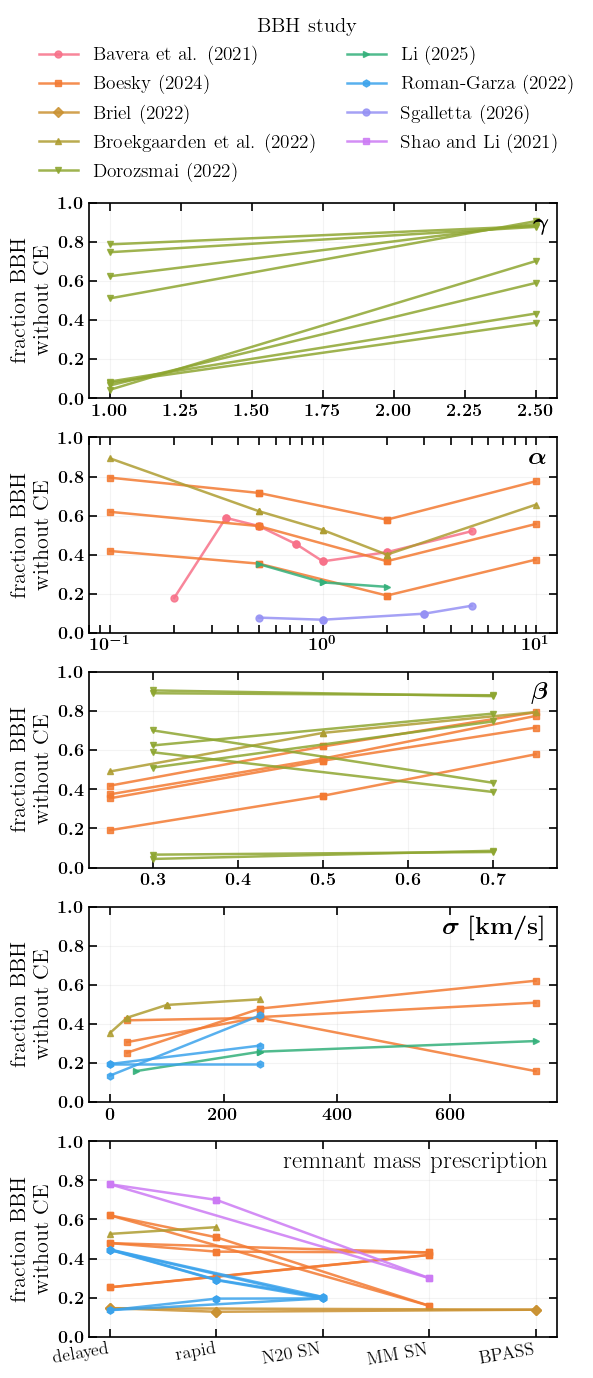

In [56]:
path = path_to_file
DCOlabel = "BH-BH"

fig = plot_withoutCE_fraction_vs_parameters_static(
    path_to_file=path,
    parameters=[r"$\gamma$" ,r"$\alpha$", r"$\beta$",  r"$\sigma$", "remnant mass prescription"],
    DCOlabel=DCOlabel,
    ncols=1,
    palette_name="husl",
    parameter_map={
        r"$\gamma$":"CE gamma",
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["delayed", "rapid", "N20 SN", "MM SN"]
    },
    alpha_logx=True,
)

fig.savefig(
    f"Output_Figures/Fig9_{DCOlabel}_withoutCE_fraction_vs_parameters.pdf",
    bbox_inches="tight"
)
plt.show()


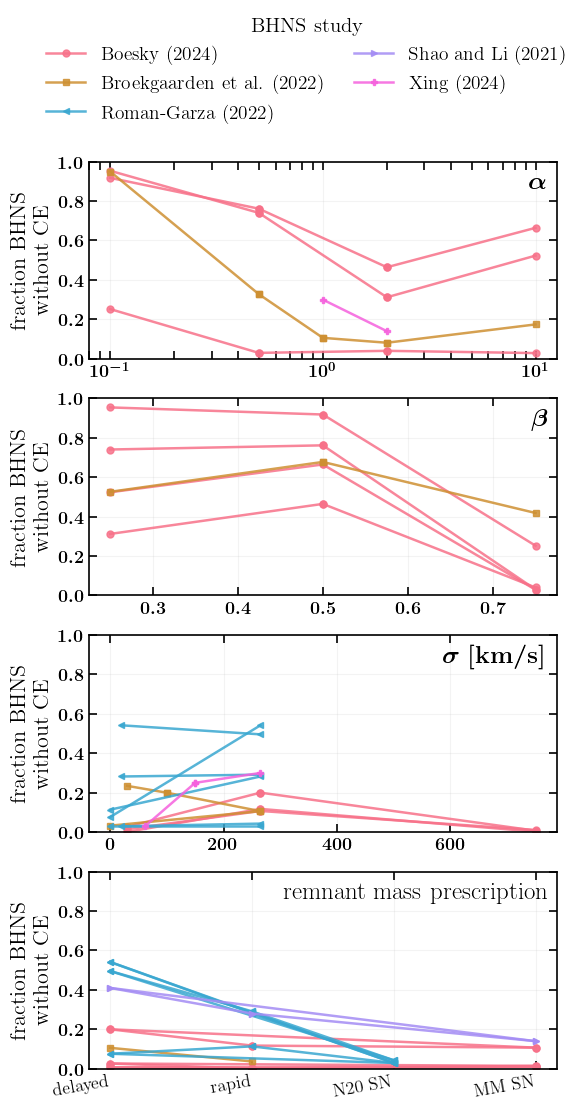

In [57]:
path = path_to_file
DCOlabel = "BH-NS"

fig = plot_withoutCE_fraction_vs_parameters_static(
    path_to_file=path,
    parameters=[ r"$\alpha$", r"$\beta$",  r"$\sigma$", "remnant mass prescription"],
    DCOlabel=DCOlabel,
    ncols=1,
    palette_name="husl",
    parameter_map={
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["delayed", "rapid", "N20 SN", "MM SN"]
    },
    alpha_logx=True,
)

fig.savefig(
    f"Output_Figures/Fig9_{DCOlabel}_withoutCE_fraction_vs_parameters.pdf",
    bbox_inches="tight"
)
plt.show()


## interactive version of the code 

In [6]:
## interactive version of the code 

import os
import math
from typing import Sequence, Optional, Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_withoutCE_fraction_vs_parameters_interactive(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols: int = 1,
    panel_h_px: int = 260,
    panel_w_px: int = 900,
    marker_size: float = 8,
    line_width: float = 2.0,
    line_alpha: float = 0.9,
    palette_name: str = "husl",
    show_study_legend: bool = True,
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,
    sigma_logx: bool = False,
    parameter_map: Optional[Dict[str, str]] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
    hover_spec_columns: Optional[List[str]] = None,
):
    """
    Interactive Plotly version of the without-CE fraction vs parameter figure.

    Each subplot is built from all relation rows that share the same value
    in the `using` column.

    Hover text includes:
      - study
      - from/to model names
      - from/to option values
      - y-values
      - selected assumptions from simulation_specs.csv for both endpoint models
    """

    # ---------------- helpers ----------------
    def normalize_text(s: Any) -> str:
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return ""
        return str(s).strip()

    def normalize_key(s: Any) -> str:
        return normalize_text(s).lower()

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        out = str(o).strip().replace("$", "").strip()

        if out.lower() == "n20":
            out = "N20 SN"
        elif out.lower() == "mm":
            out = "MM SN"

        return out

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    def rgba_from_rgb(rgb, alpha=1.0):
        r, g, b = [int(round(255 * x)) for x in rgb]
        return f"rgba({r},{g},{b},{alpha})"

    def make_specs_html(model_name: str) -> str:
        if df_specs is None or model_name not in df_specs.index:
            return "No specs found"

        row = df_specs.loc[model_name]

        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        cols_to_use = hover_spec_columns
        if cols_to_use is None:
            cols_to_use = [c for c in df_specs.columns if not c.lower().startswith("unnamed")]

        bits = []
        for col in cols_to_use:
            if col not in row.index:
                continue
            val = row[col]
            if pd.isna(val):
                continue
            bits.append(f"<b>{col}</b>: {val}")

        return "<br>".join(bits) if bits else "No specs found"

    # ---------------- defaults ----------------
    if category_orders is None:
        category_orders = {}

    if parameter_map is None:
        parameter_map = {
            r"$\beta$": "beta",
            r"$\alpha$": "alpha",
            "remnant mass prescription": "supernova",
            r"$\sigma$": "sigma",
        }

    # ---------------- load relations ----------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    rel_path = os.path.join(path_to_file, relation_file)
    df_rel = pd.read_csv(rel_path)

    required_rel_cols = {
        "legend",
        "from_modelname",
        "to_modelname",
        "from_option",
        "to_option",
        "using",
    }
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    df_rel = df_rel.copy()
    df_rel["using_norm"] = df_rel["using"].apply(normalize_key)

    # ---------------- load rates ----------------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    rates_path = os.path.join(path_to_file, rates_file)
    df_rates = pd.read_csv(rates_path)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    df_rates = df_rates.set_index("model")

    # ---------------- optional specs load ----------------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
        else:
            df_specs = None
    else:
        df_specs = None

    # ---------------- selector ----------------
    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        using_value = parameter_map.get(param_user, param_user)
        using_norm = normalize_key(using_value)
        return df[df["using_norm"] == using_norm].copy()

    # ---------------- subplot geometry ----------------
    n_panels = len(parameters)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n_panels / ncols))

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        shared_yaxes=True,
        vertical_spacing=0.08,
        horizontal_spacing=0.08,
    )

    # ---------------- colors and markers by study ----------------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))
    color_map = {leg: rgba_from_rgb(palette[i % len(palette)], alpha=line_alpha) for i, leg in enumerate(legends_sorted)}

    marker_list = ["circle", "square", "diamond", "triangle-up", "triangle-down",
                   "triangle-left", "triangle-right", "cross", "x", "star", "hexagon"]
    marker_map = {leg: marker_list[i % len(marker_list)] for i, leg in enumerate(legends_sorted)}

    # ---------------- add traces ----------------
    legend_seen = set()

    for k, p_user in enumerate(parameters):
        row = (k // ncols) + 1
        col = (k % ncols) + 1

        dfp = select_rows_for_parameter(df_rel, str(p_user))

        if dfp.empty:
            continue

        # Gather options
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]

        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # Category ordering
        order = None
        if str(p_user) in category_orders:
            desired = [str(x) for x in category_orders[str(p_user)]]
            present = []
            for o in opts:
                if o not in present:
                    present.append(o)
            order = [x for x in desired if x in present] + [x for x in present if x not in desired]
        elif not is_numeric:
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        cat_to_x = {}
        x_to_cat = {}
        if not is_numeric:
            for i_cat, cat in enumerate(order):
                cat_to_x[cat] = i_cat
                x_to_cat[i_cat] = cat

        # Add one trace per relationship segment
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]
            color_here = color_map.get(leg, "rgba(120,120,120,0.9)")
            marker_here = marker_map[leg]

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]

                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1 = float(df_rates.loc[m1, "fraction without common envelope"])
                y2 = float(df_rates.loc[m2, "fraction without common envelope"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)

                    using_value = parameter_map.get(str(p_user), str(p_user))
                    using_norm = normalize_key(using_value)

                    if alpha_logx and using_norm == "alpha" and (x1 <= 0 or x2 <= 0):
                        continue
                    if sigma_logx and using_norm == "sigma" and (x1 <= 0 or x2 <= 0):
                        continue
                else:
                    if xo1 not in cat_to_x or xo2 not in cat_to_x:
                        continue
                    x1 = cat_to_x[xo1]
                    x2 = cat_to_x[xo2]

                # In-panel label
                if r"\sigma" in str(p_user):
                    panel_label = r"$\sigma\ \mathrm{[km/s]}$"
                else:
                    panel_label = str(p_user)

                from_specs_html = make_specs_html(m1)
                to_specs_html = make_specs_html(m2)

                hover_text = (
                    f"<b>Study</b>: {leg}<br>"
                    f"<b>Parameter</b>: {panel_label}<br>"
                    f"<b>From model</b>: {m1}<br>"
                    f"<b>To model</b>: {m2}<br>"
                    f"<b>From option</b>: {xo1}<br>"
                    f"<b>To option</b>: {xo2}<br>"
                    f"<b>From without-CE fraction</b>: {y1:.4f}<br>"
                    f"<b>To without-CE fraction</b>: {y2:.4f}<br>"
                    f"<br><b>{m1} assumptions</b><br>{from_specs_html}"
                    f"<br><br><b>{m2} assumptions</b><br>{to_specs_html}"
                )

                show_legend_this_trace = show_study_legend and (leg not in legend_seen)

                fig.add_trace(
                    go.Scatter(
                        x=[x1, x2],
                        y=[y1, y2],
                        mode="lines+markers",
                        line=dict(color=color_here, width=line_width),
                        marker=dict(
                            symbol=marker_here,
                            size=marker_size,
                            color=color_here,
                            line=dict(width=0.5, color="rgba(0,0,0,0.5)")
                        ),
                        name=str(leg),
                        legendgroup=str(leg),
                        showlegend=show_legend_this_trace,
                        hovertemplate="%{text}<extra></extra>",
                        text=[hover_text, hover_text],
                    ),
                    row=row,
                    col=col,
                )

                if show_legend_this_trace:
                    legend_seen.add(leg)

        # Format x-axis
        axis_id = "" if (row == 1 and col == 1) else str((row - 1) * ncols + col)

        if is_numeric:
            using_value = parameter_map.get(str(p_user), str(p_user))
            using_norm = normalize_key(using_value)

            axis_type = "log" if (
                (alpha_logx and using_norm == "alpha") or
                (sigma_logx and using_norm == "sigma")
            ) else "linear"

            fig.update_xaxes(
                type=axis_type,
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                row=row,
                col=col,
            )
        else:
            tickvals = list(x_to_cat.keys())
            ticktext = list(x_to_cat.values())

            fig.update_xaxes(
                tickmode="array",
                tickvals=tickvals,
                ticktext=ticktext,
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                tickangle=10,
                row=row,
                col=col,
            )

        # Format y-axis
        fig.update_yaxes(
            range=list(ylim),
            showline=True,
            linewidth=1.2,
            linecolor="black",
            mirror=True,
            ticks="inside",
            ticklen=6,
            tickwidth=1.2,
            title_text="without CE fraction" if col == 1 else None,
            row=row,
            col=col,
        )

        # Add in-panel annotation
        if r"\sigma" in str(p_user):
            panel_text = r"$\sigma\ \mathrm{[km/s]}$"
        else:
            panel_text = str(p_user)

        fig.add_annotation(
            x=0.98,
            y=0.95,
            xref=f"x{axis_id} domain",
            yref=f"y{axis_id} domain",
            text=panel_text,
            showarrow=False,
            xanchor="right",
            yanchor="top",
            font=dict(size=18, color="black"),
            align="right",
            bgcolor="rgba(255,255,255,0.0)",
        )

    # ---------------- layout ----------------
    total_height = max(350, panel_h_px * nrows)
    total_width = panel_w_px if ncols == 1 else int(panel_w_px * ncols / 1.15)

    fig.update_layout(
        width=total_width,
        height=total_height,
        template="plotly_white",
        hovermode="closest",
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=70, r=30, t=110, b=60),
        legend=dict(
            title="Study",
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.08,
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.0)",
        ),
    )

    return fig



In [39]:
import plotly.io as pio
pio.renderers.default = "browser"


path = path_to_file
DCOlabel = "BH-BH"

fig_int = plot_withoutCE_fraction_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel=DCOlabel,
    ncols=1,
    hover_spec_columns=["label_1", "label_2", "label_3", "label_4"],
    parameter_map={
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["BPASS", "N20 SN", "delayed", "rapid", "MM SN" ]
    },
    alpha_logx=True,
    sigma_logx=False,
    palette_name="husl",
)

fig_int.show()


fig_int.write_html(
    f"Output_Figures/Fig9_{DCOlabel}_withoutCE_fraction_vs_parameters_interactive.html",
    include_plotlyjs="cdn"
)



In [9]:
import plotly.io as pio
pio.renderers.default = "browser"


path = path_to_file
DCOlabel = "BH-NS"

fig_int = plot_withoutCE_fraction_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel=DCOlabel,
    ncols=1,
    hover_spec_columns=["label_1", "label_2", "label_3", "label_4"],
    parameter_map={
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["BPASS", "N20 SN", "delayed", "rapid", "MM SN" ]
    },
    alpha_logx=True,
    sigma_logx=False,
    palette_name="husl",
)

fig_int.show()


fig_int.write_html(
    f"Output_Figures/Fig9_{DCOlabel}_withoutCE_fraction_vs_parameters_interactive.html",
    include_plotlyjs="cdn"
)



In [27]:
import os
import math
from typing import Sequence, Optional, Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots





## note that this has a duplicate in Figure 3 function, make sure to update both (or in the future, have this file seperate and import it)
def obtain_fc_dict():
    """
    Returns a dictionary defining formation channel (fc) specifications.

    Each top-level key corresponds to a grouping of formation channels 
    (e.g., 'CE_simple', 'CE_detailed', or 'total').  
    Each group contains either a list of 'channels' (with properties) 
    or a single entry (for 'total').
    """


    palette = {
        # Neutrals
        "gray_light":  "#e0e0e0",
        "gray_dark":   "#C2C2C2",

        # Non-CE warm family
        "orange_main": "#FFA630",
        "orange_sub":  "#ffc857",
        "orange_soft": "#f4a259",
        "red_soft":    "#e45756",
        "rose":        "#d96c75",
        "terracotta":  "#bc4b51",
        "peach":       "#ffb5a7",

        # CE cool family
        "blue_main":   "#00A7E1",
        "blue_light":  "#5dade2",
        "blue_mid":    "#0474BA",
        "blue_dark":   "#004e89",
        "indigo":      "#3a3d98",   # new deep indigo for AIC
        "teal_light":  "#20b2aa",
        "green_blue":  "#58AD8B",
        "aqua":        "#00bfc4",
        "seafoam":     "#8dd3c7",
        "mint":        "#9de0ad",
    }


    fc_dict = {
        # A simplified common-envelope grouping (just two channels).
        "CE_simple": {
            "channels": [
                {"name": "fraction without common envelope", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope', "axlabel":"fraction without CE"},
                {"name": "fraction with common envelope",    "color":palette["blue_main"],   "hatch": '//' , "label":'with common envelope', "axlabel":"fraction with CE"},
                {"name": "fraction not specified",           "color":palette[ "gray_dark"],  "hatch":None,   "label":'not specified'}
            ],
            "label_ncols":3
        },

        
        "CE_detailed": {
            "channels": [
                
                # --- Non-CE channels (warm hues, all unique) ---
                {"name": "without CE (no detail specified)", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope'},
                {"name": "SMT before and after channel",     "color":palette["red_soft"],    "hatch": '...', "label":'classic only stable'},
                {"name": "SMT+NON",                          "color":palette["rose"],        "hatch": '...', "label":'SMT + NON'},
                {"name": "NON+SMT",                          "color":palette["orange_soft"], "hatch": '...', "label":'NON+SMT'},
                {"name": "NON + NON",                        "color":palette["terracotta"],  "hatch": '...', "label":'NON+NON'},
                {"name": "channel V intrinsic (z=0) other without CE", "color":palette["peach"], "hatch": 'ooo', "label":'other without CE'},
                {"name": "CHE",                              "color":palette["orange_sub"],     "hatch":'...',   "label":'CHE (no MT)'},
                # --- CE channels (cool hues, all unique) ---
                {"name": "with CE (no detail specified)",                 "color":palette["blue_main"],  "hatch": "\\", "label":'with common envelope'},
                
                {"name": "channel I intrinsic (z=0) classic CE (SMT+CE)", "color":palette["blue_light"], "hatch": "//", "label":'classic CE'},
                {"name": "channel III intrinsic (z=0) SCCE",              "color":palette["blue_mid"],   "hatch": "\\", "label":'single-core CE'},
                {"name": "channel IV intrinsic (z=0) DCCE",               "color":palette["teal_light"], "hatch": '//', "label":'double-core CE'},
                
                {"name": "CEE + SMT",                                     "color":palette["green_blue"], "hatch": '//', "label":'CEE + SMT'},
                {"name": "CEE+CEE",                                       "color":palette["aqua"],       "hatch": "\\", "label":'CEE+CEE'},
                {"name": "NON+CEE",                                       "color":palette["seafoam"],    "hatch": '//', "label":'NON+CEE'},
                {"name": "CEE+NON",                                       "color":palette["mint"],       "hatch": '//', "label":'CEE+NON'},

                {"name": "channel radCEE",  "color":palette["blue_dark"], "hatch": '\\', "label":'radiative CE'},
                {"name": "channel convCEE", "color":palette["teal_light"], "hatch": '//', "label":'convective CE'},
                {"name": "channel V intrinsic (z=0) other with CE", "color":palette["seafoam"], "hatch": "\\", "label":'other with CE'},
#                 {"name": "channel AIC with CE", "color":palette["indigo"], "hatch": '//', "label":'AIC with CE'},


                {"name": "channel V intrinsic (z=0) CE not specified",    "color":palette["gray_dark"],  "hatch": None, "label":'other CE not specified'},
            ],
            "label_ncols":5
        },

        # A total merger rate across all intrinsic channels.
        "total": {
            "name": "All intrinsic (z=0) [Gpc^-3 yr^-1]",
            "color": "black",
            "hatch": None,
            "label":r"All intrinsic ($z\sim0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]",
            "label_ncols":1,
            "axlabel":r"$\mathcal{R}_{\rm{m}}$ \  $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]"
#             "axlabel":r"Total local merger rate", # % ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]
        },
    }

    return fc_dict


def plot_ce_rates_vs_parameters_interactive(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    marker_size: float = 8,
    line_width: float = 2.0,
    line_alpha: float = 0.9,
    palette_name: str = "husl",
    show_study_legend: bool = True,
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,
    sigma_logx: bool = False,
    parameter_map: Optional[Dict[str, str]] = None,
    yscale: str = "log",   # "log" or "linear"
    hover_spec_columns: Optional[List[str]] = None,
    panel_h_px: int = 260,
    panel_w_px: int = 430,
    shared_y_within_row: bool = False,
):
    """
    Interactive Plotly figure with TWO PANELS per parameter:
      left  = absolute without-CE rate
      right = absolute with-CE rate

    x-axis = parameter value / category
    y-axis = absolute rate in Gpc^-3 yr^-1

    Returns
    -------
    plotly.graph_objects.Figure
    """

    # ---------------- helpers ----------------
    def normalize_text(s: Any) -> str:
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return ""
        return str(s).strip()

    def normalize_key(s: Any) -> str:
        return normalize_text(s).lower()

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        out = str(o).strip().replace("$", "").strip()

        if out.lower() == "n20":
            out = "N20 SN"
        elif out.lower() == "mm":
            out = "MM SN"

        return out

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    def rgba_from_rgb(rgb, alpha=1.0):
        r, g, b = [int(round(255 * x)) for x in rgb]
        return f"rgba({r},{g},{b},{alpha})"

    def make_specs_html(model_name: str) -> str:
        if df_specs is None or model_name not in df_specs.index:
            return "No specs found"

        row = df_specs.loc[model_name]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        cols_to_use = hover_spec_columns
        if cols_to_use is None:
            cols_to_use = [c for c in df_specs.columns if not c.lower().startswith("unnamed")]

        bits = []
        for col in cols_to_use:
            if col not in row.index:
                continue
            val = row[col]
            if pd.isna(val):
                continue
            bits.append(f"<b>{col}</b>: {val}")

        return "<br>".join(bits) if bits else "No specs found"

    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        using_value = parameter_map.get(param_user, param_user)
        using_norm = normalize_key(using_value)
        return df[df["using_norm"] == using_norm].copy()

    # ---------------- defaults ----------------
    if category_orders is None:
        category_orders = {}

    if parameter_map is None:
        parameter_map = {
            r"$\beta$": "beta",
            r"$\alpha$": "alpha",
            "remnant mass prescription": "supernova",
            r"$\sigma$": "sigma",
        }

    # ---------------- load relations ----------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    rel_path = os.path.join(path_to_file, relation_file)
    df_rel = pd.read_csv(rel_path)

    required_rel_cols = {
        "legend",
        "from_modelname",
        "to_modelname",
        "from_option",
        "to_option",
        "using",
    }
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    df_rel = df_rel.copy()
    df_rel["using_norm"] = df_rel["using"].apply(normalize_key)

    # ---------------- load rates ----------------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    rates_path = os.path.join(path_to_file, rates_file)
    df_rates = pd.read_csv(rates_path)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")

    fc_dict = obtain_fc_dict()
    total_rate_col = fc_dict["total"]["name"]

    required_rate_cols = [
        "fraction without common envelope",
        "fraction with common envelope",
        total_rate_col,
    ]
    missing_rate = [c for c in required_rate_cols if c not in df_rates.columns]
    if missing_rate:
        raise ValueError(f"Rates file missing required columns: {missing_rate}")

    df_rates = df_rates.set_index("model")

    # absolute rates
    df_rates["rate_without_CE"] = (
        df_rates["fraction without common envelope"].astype(float)
        * df_rates[total_rate_col].astype(float)
    )
    df_rates["rate_with_CE"] = (
        df_rates["fraction with common envelope"].astype(float)
        * df_rates[total_rate_col].astype(float)
    )

    # ---------------- optional specs load ----------------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
        else:
            df_specs = None
    else:
        df_specs = None

    # ---------------- subplot geometry ----------------
    n_params = len(parameters)
    nrows = n_params
    ncols = 2  # left = without CE, right = with CE

    subplot_titles = []
    for p in parameters:
        if r"\sigma" in str(p):
            p_label = r"$\sigma\ \mathrm{[km/s]}$"
        else:
            p_label = str(p)

        subplot_titles.extend([
            f"{p_label}: without CE rate",
            f"{p_label}: with CE rate",
        ])

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        shared_yaxes=shared_y_within_row,
        vertical_spacing=0.08,
        horizontal_spacing=0.10,
        subplot_titles=subplot_titles,
    )

    # ---------------- colors and markers by study ----------------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))
    color_map = {
        leg: rgba_from_rgb(palette[i % len(palette)], alpha=line_alpha)
        for i, leg in enumerate(legends_sorted)
    }

    marker_list = [
        "circle", "square", "diamond", "triangle-up", "triangle-down",
        "triangle-left", "triangle-right", "cross", "x", "star", "hexagon"
    ]
    marker_map = {leg: marker_list[i % len(marker_list)] for i, leg in enumerate(legends_sorted)}

    legend_seen = set()

    # ---------------- precompute y ranges ----------------
    y_without = df_rates["rate_without_CE"].astype(float).values
    y_with = df_rates["rate_with_CE"].astype(float).values

    def positive_range(vals):
        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]
        if len(vals) == 0:
            return (1e-6, 1.0)
        return (np.min(vals), np.max(vals))

    ywo_min, ywo_max = positive_range(y_without)
    ywi_min, ywi_max = positive_range(y_with)

    # add padding
    if yscale == "log":
        ywo_min /= 1.25
        ywo_max *= 1.25
        ywi_min /= 1.25
        ywi_max *= 1.25
    else:
        ywo_pad = 0.05 * (ywo_max - ywo_min) if ywo_max > ywo_min else 1.0
        ywi_pad = 0.05 * (ywi_max - ywi_min) if ywi_max > ywi_min else 1.0
        ywo_min = max(0.0, ywo_min - ywo_pad)
        ywo_max = ywo_max + ywo_pad
        ywi_min = max(0.0, ywi_min - ywi_pad)
        ywi_max = ywi_max + ywi_pad

    # ---------------- add traces ----------------
    for k, p_user in enumerate(parameters):
        row = k + 1
        dfp = select_rows_for_parameter(df_rel, str(p_user))

        if dfp.empty:
            continue

        # Gather options
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]

        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # Category ordering
        order = None
        if str(p_user) in category_orders:
            desired = [str(x) for x in category_orders[str(p_user)]]
            present = []
            for o in opts:
                if o not in present:
                    present.append(o)
            order = [x for x in desired if x in present] + [x for x in present if x not in desired]
        elif not is_numeric:
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        cat_to_x = {}
        x_to_cat = {}
        if not is_numeric:
            for i_cat, cat in enumerate(order):
                cat_to_x[cat] = i_cat
                x_to_cat[i_cat] = cat

        # add traces for each study
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]
            color_here = color_map.get(leg, "rgba(120,120,120,0.9)")
            marker_here = marker_map[leg]

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]

                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1_wo = float(df_rates.loc[m1, "rate_without_CE"])
                y2_wo = float(df_rates.loc[m2, "rate_without_CE"])
                y1_wi = float(df_rates.loc[m1, "rate_with_CE"])
                y2_wi = float(df_rates.loc[m2, "rate_with_CE"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)

                    using_value = parameter_map.get(str(p_user), str(p_user))
                    using_norm = normalize_key(using_value)

                    if alpha_logx and using_norm == "alpha" and (x1 <= 0 or x2 <= 0):
                        continue
                    if sigma_logx and using_norm == "sigma" and (x1 <= 0 or x2 <= 0):
                        continue
                else:
                    if xo1 not in cat_to_x or xo2 not in cat_to_x:
                        continue
                    x1 = cat_to_x[xo1]
                    x2 = cat_to_x[xo2]

                if r"\sigma" in str(p_user):
                    panel_label = r"$\sigma\ \mathrm{[km/s]}$"
                else:
                    panel_label = str(p_user)

                from_specs_html = make_specs_html(m1)
                to_specs_html = make_specs_html(m2)

                hover_wo = (
                    f"<b>Study</b>: {leg}<br>"
                    f"<b>Parameter</b>: {panel_label}<br>"
                    f"<b>Channel</b>: without CE<br>"
                    f"<b>From model</b>: {m1}<br>"
                    f"<b>To model</b>: {m2}<br>"
                    f"<b>From option</b>: {xo1}<br>"
                    f"<b>To option</b>: {xo2}<br>"
                    f"<b>From without-CE rate</b>: {y1_wo:.4e}<br>"
                    f"<b>To without-CE rate</b>: {y2_wo:.4e}<br>"
                    f"<br><b>{m1} assumptions</b><br>{from_specs_html}"
                    f"<br><br><b>{m2} assumptions</b><br>{to_specs_html}"
                )

                hover_wi = (
                    f"<b>Study</b>: {leg}<br>"
                    f"<b>Parameter</b>: {panel_label}<br>"
                    f"<b>Channel</b>: with CE<br>"
                    f"<b>From model</b>: {m1}<br>"
                    f"<b>To model</b>: {m2}<br>"
                    f"<b>From option</b>: {xo1}<br>"
                    f"<b>To option</b>: {xo2}<br>"
                    f"<b>From with-CE rate</b>: {y1_wi:.4e}<br>"
                    f"<b>To with-CE rate</b>: {y2_wi:.4e}<br>"
                    f"<br><b>{m1} assumptions</b><br>{from_specs_html}"
                    f"<br><br><b>{m2} assumptions</b><br>{to_specs_html}"
                )

                show_legend_this_trace = show_study_legend and (leg not in legend_seen)

                # left panel: without CE
                if not (yscale == "log" and (y1_wo <= 0 or y2_wo <= 0)):
                    fig.add_trace(
                        go.Scatter(
                            x=[x1, x2],
                            y=[y1_wo, y2_wo],
                            mode="lines+markers",
                            line=dict(color=color_here, width=line_width),
                            marker=dict(
                                symbol=marker_here,
                                size=marker_size,
                                color=color_here,
                                line=dict(width=0.5, color="rgba(0,0,0,0.5)")
                            ),
                            name=str(leg),
                            legendgroup=str(leg),
                            showlegend=show_legend_this_trace,
                            hovertemplate="%{text}<extra></extra>",
                            text=[hover_wo, hover_wo],
                        ),
                        row=row,
                        col=1,
                    )

                # right panel: with CE
                if not (yscale == "log" and (y1_wi <= 0 or y2_wi <= 0)):
                    fig.add_trace(
                        go.Scatter(
                            x=[x1, x2],
                            y=[y1_wi, y2_wi],
                            mode="lines+markers",
                            line=dict(color=color_here, width=line_width),
                            marker=dict(
                                symbol=marker_here,
                                size=marker_size,
                                color=color_here,
                                line=dict(width=0.5, color="rgba(0,0,0,0.5)")
                            ),
                            name=str(leg),
                            legendgroup=str(leg),
                            showlegend=False,
                            hovertemplate="%{text}<extra></extra>",
                            text=[hover_wi, hover_wi],
                        ),
                        row=row,
                        col=2,
                    )

                if show_legend_this_trace:
                    legend_seen.add(leg)

        # ---- x-axis formatting for both panels in this row ----
        for col in [1, 2]:
            if is_numeric:
                using_value = parameter_map.get(str(p_user), str(p_user))
                using_norm = normalize_key(using_value)

                axis_type = "log" if (
                    (alpha_logx and using_norm == "alpha") or
                    (sigma_logx and using_norm == "sigma")
                ) else "linear"

                fig.update_xaxes(
                    type=axis_type,
                    showline=True,
                    linewidth=1.2,
                    linecolor="black",
                    mirror=True,
                    ticks="inside",
                    ticklen=6,
                    tickwidth=1.2,
                    row=row,
                    col=col,
                )
            else:
                tickvals = list(x_to_cat.keys())
                ticktext = list(x_to_cat.values())

                fig.update_xaxes(
                    tickmode="array",
                    tickvals=tickvals,
                    ticktext=ticktext,
                    showline=True,
                    linewidth=1.2,
                    linecolor="black",
                    mirror=True,
                    ticks="inside",
                    ticklen=6,
                    tickwidth=1.2,
                    tickangle=10,
                    row=row,
                    col=col,
                )

        # ---- y-axis formatting ----
        if yscale == "log":
            fig.update_yaxes(
                type="log",
                range=[np.log10(ywo_min), np.log10(ywo_max)],
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                title_text="without CE rate [Gpc-3/yr]",
                row=row,
                col=1,
            )
            fig.update_yaxes(
                type="log",
                range=[np.log10(ywi_min), np.log10(ywi_max)],
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                title_text="with CE rate [Gpc^-3 yr^-1]",
                row=row,
                col=2,
            )
        else:
            fig.update_yaxes(
                range=[ywo_min, ywo_max],
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                title_text="without CE rate [Gpc-3/yr]",
                row=row,
                col=1,
            )
            fig.update_yaxes(
                range=[ywi_min, ywi_max],
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                title_text="with CE rate [Gpc-3/yr]",
                row=row,
                col=2,
            )

    # ---------------- layout ----------------
    total_height = max(350, panel_h_px * nrows)
    total_width = int(panel_w_px * 2)

    fig.update_layout(
        width=total_width,
        height=total_height,
        template="plotly_white",
        hovermode="closest",
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=90, r=30, t=90, b=60),
        legend=dict(
            title="Study",
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.02,
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.0)",
        ),
    )

    return fig



In [37]:
fig = plot_ce_rates_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel="BH-BH",
    panel_h_px=250,
    panel_w_px=500,
    marker_size=8,
    line_width=2.0,
    palette_name="husl",
    alpha_logx=True,
    sigma_logx=False,
    yscale="log",
)

fig.show()

In [38]:
fig = plot_ce_rates_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel="BH-NS",
    panel_h_px=250,
    panel_w_px=500,
    marker_size=8,
    line_width=2.0,
    palette_name="husl",
    alpha_logx=True,
    sigma_logx=False,
    yscale="log",
)

fig.show()

In [36]:
fig = plot_ce_rates_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel="NS-NS",
    panel_h_px=250,
    panel_w_px=500,
    marker_size=8,
    line_width=2.0,
    palette_name="husl",
    alpha_logx=True,
    sigma_logx=False,
    yscale="log",
)

fig.show()